<a href="https://colab.research.google.com/github/sj-workbench/years_of_learnings/blob/main/handling_mixeddata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import pandas as pd

In [20]:
df = pd.read_csv('/content/titanic.csv')
df.sample(5)

,Cabin,Ticket,number,Survived
542,NaN,347082,1,0
866,NaN,SC/PARIS 2149,2,1
686,NaN,3101295,4,0
640,NaN,350050,5,0
708,NaN,113781,4,1


In [21]:
df['number'].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

<Axes: xlabel='number'>

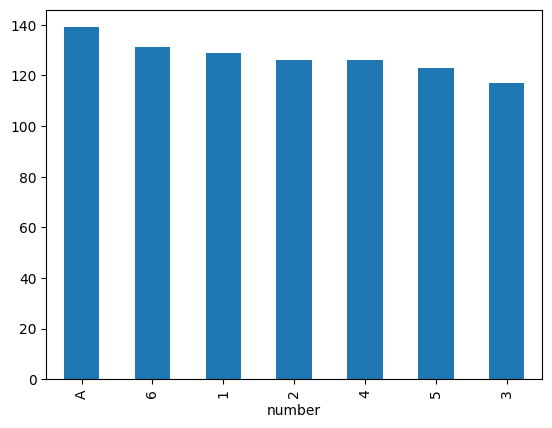

In [22]:
df['number'].value_counts().plot.bar()

In [23]:
# Extract numerical part
df['numerical_data'] = pd.to_numeric(df['number'], errors='coerce', downcast = 'integer')
df['numerical_data'].isnull().sum()

np.int64(139)

In [24]:
# extract categorical part
df['categorical_data'] = np.where(df['numerical_data'].isnull(), df['number'], np.nan)
df.head(5)

,Cabin,Ticket,number,Survived,numerical_data,categorical_data
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [25]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [28]:
df['categorical_num'] = df['Cabin'].str.extract('(\d+)')
df['categorical_cat'] = df['Cabin'].str[0]
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1008/1016247770.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['categorical_num'] = df['Cabin'].str.extract('(\d+)')


,Cabin,Ticket,number,Survived,numerical_data,categorical_data,categorical_num,categorical_cat
0,NaN,A/5 21171,5,0,NaN,NaN,NaN,NaN
1,C85,PC 17599,3,1,85,C,85,C
2,NaN,STON/O2. 3101282,6,1,NaN,NaN,NaN,NaN
3,C123,113803,3,1,123,C,123,C
4,NaN,373450,A,0,NaN,NaN,NaN,NaN


Handling Date and time

In [33]:
dates = pd.read_csv('/content/orders.csv')
times = pd.read_csv('/content/messages.csv')
print(dates.head())
print(times.head())

         date  product_id  city_id  orders
0  2019-12-10        5628       25       3
1  2018-08-15        3646       14     157
2  2018-10-23        1859       25       1
3  2019-08-17        7292       25       1
4  2019-01-06        4344       25       3
                  date                                                msg
0  2013-12-15 00:50:00                           ищу на сегодня мужика 37
1  2014-04-29 23:40:00   ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826
2  2012-12-30 00:21:00           Днепр.м 43 позн.с д/ж *.о  067.16.34.576
3  2014-11-28 00:31:00  КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...
4  2013-10-26 23:11:00    Зая я тебя никогда не обижу  люблю тебя!)  Даше


In [34]:
print(dates.info())
print(times.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        1000 non-null   object
 1   product_id  1000 non-null   int64 
 2   city_id     1000 non-null   int64 
 3   orders      1000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 31.4+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1000 non-null   object
 1   msg     1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB
None
